# import libs

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# load data

In [124]:
df = pd.read_csv('housing.csv')

# DATA PREPARATION


In [125]:
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [127]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## two proplems :
* outliers
* NULL in 'total_bedrooms' col

### impute NULL values

In [128]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

### Deal with outliers 

#### view count plot for each col

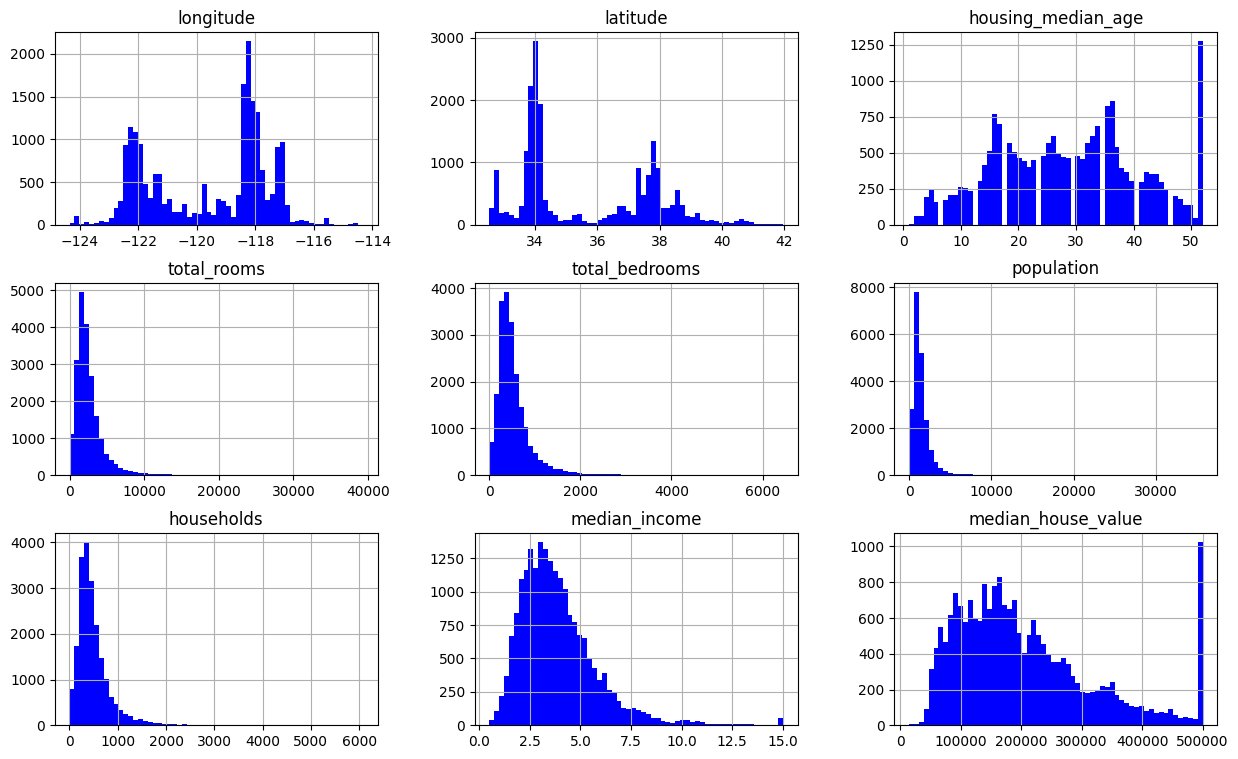

In [129]:
df.hist(bins = 60, figsize=(15,9),color='blue')
plt.show()


In [130]:
df[['total_rooms', 'population', 'total_bedrooms', 'households']].describe()


,total_rooms,population,total_bedrooms,households
count,20640.000000,20640.000000,20640.000000,20640.000000
mean,2635.763081,1425.476744,536.838857,499.539680
std,2181.615252,1132.462122,419.391878,382.329753
min,2.000000,3.000000,1.000000,1.000000
25%,1447.750000,787.000000,297.000000,280.000000
50%,2127.000000,1166.000000,435.000000,409.000000
75%,3148.000000,1725.000000,643.250000,605.000000
max,39320.000000,35682.000000,6445.000000,6082.000000


#### Remove Outliers

In [131]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

Before : 20640
After  : 18126


<Axes: >

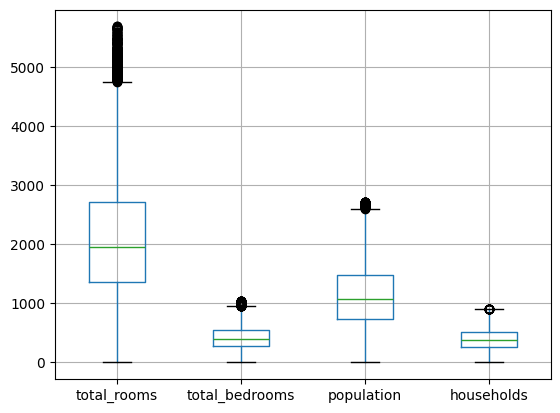

In [132]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[~((df[column] < lower_bound) | (df[column] > upper_bound))]

cols = ['total_rooms', 'total_bedrooms', 'population', 'households']

df_clean = df.copy()
for col in cols:
    df_clean = remove_outliers(df_clean, col)

print(f"Before : {len(df)}")
print(f"After  : {len(df_clean)}")

df_clean[cols].boxplot()

In [133]:
df_clean.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,18126.000000,18126.000000,18126.000000,18126.00000,18126.000000,18126.000000,18126.000000,18126.000000,18126.000000
mean,-119.618090,35.683692,29.886517,2095.62711,424.688183,1134.829582,397.575361,3.859723,205219.896723
std,2.003938,2.154863,12.333002,1039.05060,199.533966,546.628245,186.145063,1.914661,116229.058741
min,-124.350000,32.540000,1.000000,2.00000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.820000,33.940000,20.000000,1364.00000,282.000000,742.000000,265.000000,2.544450,116200.000000
50%,-118.580000,34.290000,31.000000,1956.00000,402.000000,1068.000000,377.000000,3.526800,177900.000000
75%,-118.040000,37.730000,38.000000,2719.75000,551.000000,1486.000000,518.000000,4.736100,263375.000000
max,-114.490000,41.950000,52.000000,5688.00000,1044.000000,2721.000000,908.000000,15.000100,500001.000000


#### Delete Capped data 

In [134]:
df_clean = df_clean[(df_clean['median_house_value'] < 500000) & (df_clean['housing_median_age'] <= 50)]
df_clean.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16143.000000,16143.000000,16143.000000,16143.000000,16143.000000,16143.000000,16143.000000,16143.000000,16143.000000
mean,-119.527624,35.642923,28.100725,2104.309794,429.306511,1163.760330,401.883789,3.678148,187162.788639
std,1.979726,2.169971,11.124163,1037.846301,199.623699,551.451052,186.414584,1.574878,95829.399918
min,-124.300000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.570000,33.920000,19.000000,1369.000000,285.000000,765.000000,269.000000,2.515600,112500.000000
50%,-118.490000,34.260000,29.000000,1958.000000,406.000000,1100.000000,380.000000,3.455000,168900.000000
75%,-117.990000,37.690000,36.000000,2731.000000,556.000000,1524.000000,523.500000,4.604200,240700.000000
max,-114.490000,41.950000,50.000000,5688.000000,1044.000000,2721.000000,908.000000,15.000100,499100.000000


In [135]:
df_clean['households_per_room'] = df_clean['households'] / df_clean['total_rooms']

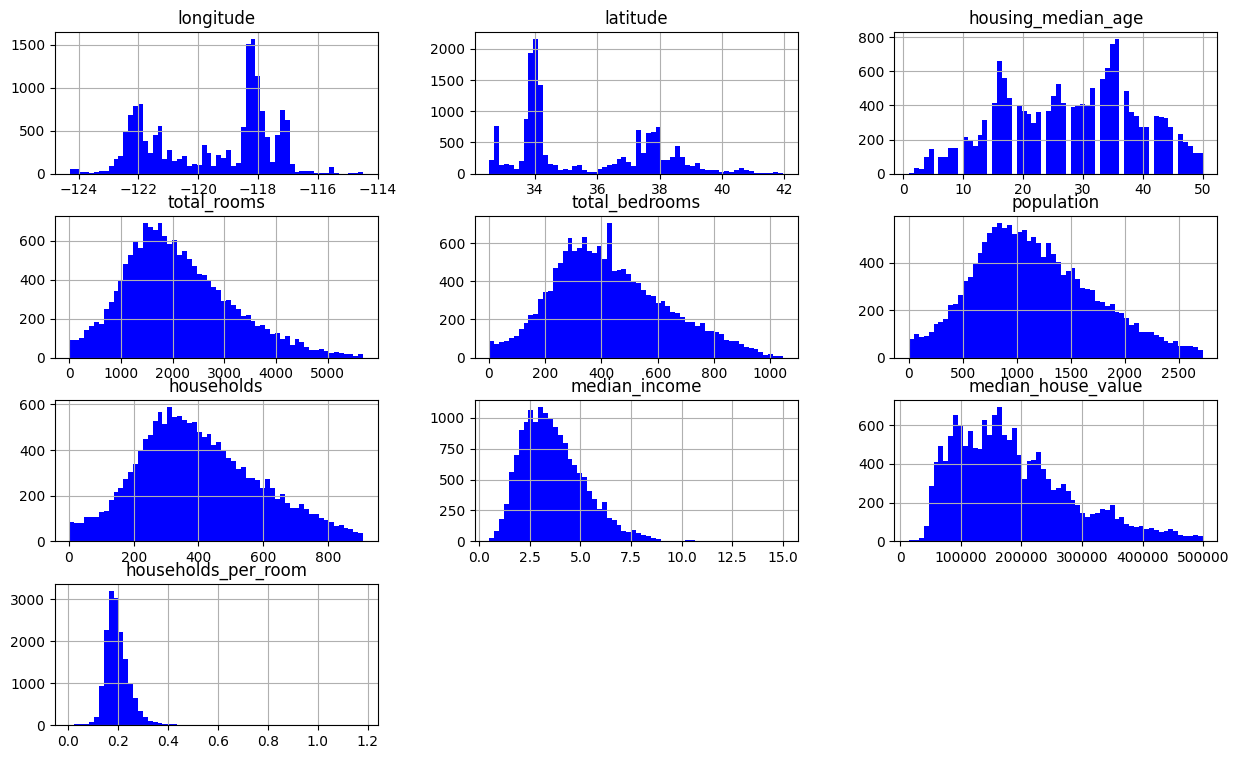

In [136]:
df_clean.hist(bins = 60, figsize=(15,9),color='blue')
plt.show()


# Data preprocessing

## spilt data

In [137]:
x = df_clean.drop('median_house_value', axis=1)
y = df_clean['median_house_value']


x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=43)

### encoding

In [138]:

x_train = pd.get_dummies(x_train, columns=['ocean_proximity'], drop_first=True)
x_test  = pd.get_dummies(x_test,  columns=['ocean_proximity'], drop_first=True)

x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

### scaling

In [139]:
from sklearn.preprocessing import StandardScaler


In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

# Model 

## Linear Regression model

In [141]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [142]:
model = LinearRegression()
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")

Mean Squared Error: 3218505213.6009583
R^2 Score: 0.6354075894527278


## GradientBoostingRegressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=43)
model.fit(x_train_scaled, y_train)
y_pred = model.predict(x_test_scaled)

r2 = r2_score(y_test, y_pred)
print(f"R² Score: {r2:.4f}")  
print(f"Test R²:     {r2_score(y_test, y_pred):.4f}")


R² Score: 0.7986


## XGboost

In [149]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
Xgb_model = xgb.XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, random_state=43)
Xgb_model.fit(x_train_scaled, y_train)
y_pred_xgb = Xgb_model.predict(x_test_scaled)

r2 = r2_score(y_test, y_pred_xgb)
print(f"R² Score: {r2:.4f}")


R² Score: 0.8177


In [150]:
param_grid = {
    'n_estimators':  [100, 200, 300 , 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':     [3, 5, 7],
    'subsample':     [0.8, 1.0],
}
 
model = GradientBoostingRegressor(random_state=43)
 
grid = GridSearchCV(
    estimator  = model,
    param_grid = param_grid,
    scoring    = 'r2',
    n_jobs     = -1,
    verbose    = 1,
)
 
grid.fit(x_train_scaled, y_train)
 
# ── 9. Evaluate ───────────────────────────────────────────────
best_model = grid.best_estimator_
y_pred     = best_model.predict(x_test_scaled)
 
print("=" * 40)
print("Best Params:", grid.best_params_)
print(f"Test R²:     {r2_score(y_test, y_pred):.4f}")
print(f"Test RMSE:   {np.sqrt(mean_squared_error(y_test, y_pred)):,.0f}")
print("=" * 40)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 0.8}
Best CV R²:  0.8169
Test R²:     0.8159
Test RMSE:   40,317


## Random forest

In [151]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=300, max_depth=5, random_state=43)
model.fit(x_train_scaled, y_train)
y_pred_randomforest = model.predict(x_test_scaled)
r2 = r2_score(y_test, y_pred_randomforest)
print(f"R² Score: {r2:.4f}")


R² Score: 0.6319
